In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("MNIST downloaded")
print(len(train_data), len(test_data))

MNIST downloaded
60000 10000


In [3]:
def get_subset(dataset, classes):
    indices = []

    for i in range(len(dataset)):
        _, label = dataset[i]
        if label in classes:
            indices.append(i)

    return Subset(dataset, indices)


taskA_train = get_subset(train_data, [0, 1, 2, 3, 4])
taskA_test  = get_subset(test_data,  [0, 1, 2, 3, 4])

taskB_train = get_subset(train_data, [5, 6, 7, 8, 9])
taskB_test  = get_subset(test_data,  [5, 6, 7, 8, 9])

print("Task A train:", len(taskA_train))
print("Task B train:", len(taskB_train))

Task A train: 30596
Task B train: 29404


In [4]:
batch_size = 128

taskA_train_loader = DataLoader(taskA_train, batch_size=batch_size, shuffle=True)
taskA_test_loader  = DataLoader(taskA_test,  batch_size=batch_size, shuffle=False)

taskB_train_loader = DataLoader(taskB_train, batch_size=batch_size, shuffle=True)
taskB_test_loader  = DataLoader(taskB_test,  batch_size=batch_size, shuffle=False)

In [5]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)


model = MLP().to(device)
print(model)

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [6]:
def train(model, loader, epochs=2, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            output = model(x)
            loss = criterion(output, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader):.4f}")

In [7]:
def evaluate(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            output = model(x)
            pred = torch.argmax(output, dim=1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    return 100 * correct / total

In [8]:
print("Training on Task A: digits 0-4")
train(model, taskA_train_loader, epochs=2)

taskA_acc_before = evaluate(model, taskA_test_loader)
taskB_acc_before = evaluate(model, taskB_test_loader)

print(f"Task A Accuracy Before Task B: {taskA_acc_before:.2f}%")
print(f"Task B Accuracy Before Task B: {taskB_acc_before:.2f}%")

Training on Task A: digits 0-4
Epoch 1/2, Loss: 0.2153
Epoch 2/2, Loss: 0.0771
Task A Accuracy Before Task B: 98.66%
Task B Accuracy Before Task B: 0.00%


In [9]:
print("Training on Task B: digits 5-9")
train(model, taskB_train_loader, epochs=2)

taskB_acc_after = evaluate(model, taskB_test_loader)
taskA_acc_after = evaluate(model, taskA_test_loader)

print(f"Task B Accuracy After Training: {taskB_acc_after:.2f}%")
print(f"Task A Accuracy After Task B: {taskA_acc_after:.2f}%")

Training on Task B: digits 5-9
Epoch 1/2, Loss: 0.8383
Epoch 2/2, Loss: 0.1490
Task B Accuracy After Training: 96.03%
Task A Accuracy After Task B: 0.00%


In [11]:
forgetting = taskA_acc_before - taskA_acc_after

print("Result ")
print(f"Task A Accuracy Before Task B: {taskA_acc_before:.2f}%")
print(f"Task A Accuracy After Task B: {taskA_acc_after:.2f}%")
print(f"Catastrophic Forgetting: {forgetting:.2f}%")

Result 
Task A Accuracy Before Task B: 98.66%
Task A Accuracy After Task B: 0.00%
Catastrophic Forgetting: 98.66%


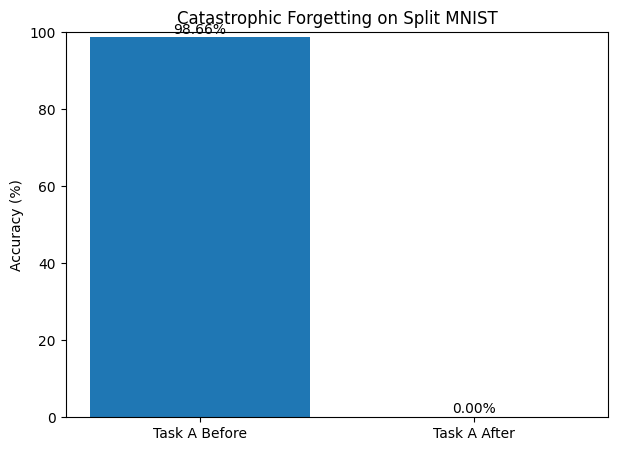

In [12]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Task A Before", "Task A After"],
    [taskA_acc_before, taskA_acc_after]
)

plt.ylabel("Accuracy (%)")
plt.title("Catastrophic Forgetting on Split MNIST")
plt.ylim(0, 100)

for i, acc in enumerate([taskA_acc_before, taskA_acc_after]):
    plt.text(i, acc + 1, f"{acc:.2f}%", ha="center")

plt.show()

In [14]:
print(taskA_acc_before)
print(taskA_acc_after)
print(taskB_acc_after)
print(model)
print(taskA_train_loader)
print(taskB_train_loader)

98.65732632807939
0.0
96.02962353425221
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [15]:
replay_model = MLP().to(device)

print("Replay model created")

Replay model created


In [16]:
train(
    replay_model,
    taskA_train_loader,
    epochs=2
)

replay_taskA_before = evaluate(
    replay_model,
    taskA_test_loader
)

print(
    "Task A Accuracy:",
    replay_taskA_before
)

Epoch 1/2, Loss: 0.2163
Epoch 2/2, Loss: 0.0772
Task A Accuracy: 98.40435882467406
